# Used Cars Data Analysis Project

* **Name:** Yonatan Faizov
* **ID:** 322332586

 ## 1. Data Loading and Initial Inspection

**Overview:**  
Here we load the used cars dataset from the CSV file ('used_cars.csv') into Python to look at the first few rows.

**Key Points:**
* The dataset has info like: 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', and 'price'.
* We check the first rows to make sure the file loaded correctly.

In [49]:
import pandas as pd
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. Dataset Information and Data Types

**Overview:**  
We use 'df.info()' to check the columns, data types, and see if any data is missing.

**Key Points:**
* The dataset has **4,009 rows** and **12 columns**.
* Some columns like 'fuel_type', 'accident', and 'clean_title' have missing values.
* Most columns are text ('str'), while 'model_year' is a number ('int64').

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


## 3. Checking Mileage Format

**Overview:**  
We check the 'milage' column to see how the numbers are stored in the dataset.

**Key Points:**
* The numbers include commas and the string ' mi.' (for example: '51,000 mi.').
* Because of this, Python reads this column as text ('str') instead of a number.

In [51]:
df['milage'].head()

0    51,000 mi.
1    34,742 mi.
2    22,372 mi.
3    88,900 mi.
4     9,835 mi.
Name: milage, dtype: str

## 4. Cleaning the Mileage Column

**Overview:**  
We clean the 'milage' column so we can use it as a numerical variable in our calculations and graphs.

**Key Steps:**
* Removed both the ' mi.' text and the commas (',') from the values.
* Converted the column data type from string ('str') to integer ('int64').

In [52]:
df['milage'] = df['milage'].str.replace('mi.','', regex=False)
df['milage'] = df['milage'].str.replace(',','', regex=False)
df['milage'] = df['milage'].astype(int)
df['milage'].head()

0    51000
1    34742
2    22372
3    88900
4     9835
Name: milage, dtype: int64

## 5. Checking Price Format

**Overview:**  
We check the 'price' column to see how car prices are formatted.

**Key Points:**
* The prices contain dollar signs ('$') and commas (',') (for example: '$10,300').
* Because of these characters, the column is currently stored as text ('str').

In [53]:
df['price'].head()

0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
Name: price, dtype: str

## 6. Cleaning the Price Column

**Overview:**  
We clean the 'price' column so we can use it for numerical analysis and graphs.

**Key Steps:**
* Removed both the dollar sign ('$') and the commas (',') from the values.
* Converted the column data type from 'str' to 'float' because prices are continuous values (can have decimals) and to handle potential missing values properly.

In [54]:
df['price'] = df['price'].str.replace('$','', regex=False)
df['price'] = df['price'].str.replace(',','', regex=False)
df['price'] = df['price'].astype(float)
df['price'].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

## 7. Checking for Missing Values

**Overview:**  
We check the dataset to see how many missing (null) values are in each column.

**Key Points:**
* We use 'df.isnull().sum()' to count missing values per column.
* Most columns are complete, but some (like 'fuel_type', 'accident', and 'clean_title') have missing entries.

In [55]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

## 8. Handling Missing Values

**Overview:**  
We fill the missing values in categorical columns so we don't lose rows of data.

**Key Steps:**
* Filled missing values in 'fuel_type', 'accident', and 'clean_title' with the string 'Unknown'.
* Verified with 'df.isnull().sum()' that there are now zero missing values in the dataset.

In [56]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('Unknown')
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

## 9. Initial Summary Statistics

**Overview:**  
We use 'df.describe()' to get a quick statistical summary of the numerical columns.

**Key Points:**
* Displays stats like count, mean, standard deviation, min, max, and percentiles for 'model_year', 'milage', and 'price'.
* The raw output displays long decimals and scientific notation (like '4.009000e+03'), which makes it hard to read.

In [57]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


## 10. Formatted Summary Statistics

**Overview:**  
We format the summary statistics to make the table clean and easy to read.

**Key Steps:**
* Rounded all values to 2 decimal places using '.round(2)' to convert scientific notation into standard numerical values.

In [58]:
df.describe().round(2)

,model_year,milage,price
count,4009.00,4009.00,4009.00
mean,2015.52,64717.55,44553.19
std,6.10,52296.60,78710.64
min,1974.00,100.00,2000.00
25%,2012.00,23044.00,17200.00
50%,2017.00,52775.00,31000.00
75%,2020.00,94100.00,49990.00
max,2024.00,405000.00,2954083.00


## 11. Price Distribution Analysis

**Overview:**  
We visualize the distribution of car prices (filtered for cars under $150,000) to understand the price range and density.

**Key Points:**
* **Libraries:** Imported 'matplotlib.pyplot' and 'seaborn' for plotting.
* **Filtering:** Filtered out extreme outliers by limiting the view to prices below $150,000.
* **Visualization:** Plotted a histogram with a Kernel Density Estimate ('kde=True') to show both the frequency counts and the overall distribution curve.

Matplotlib is building the font cache; this may take a moment.


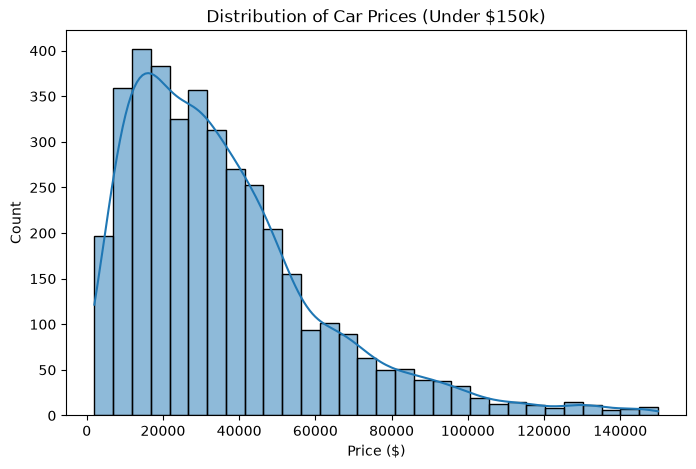

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df[df['price'] < 150000]['price'], bins=30, kde=True)
plt.title('Distribution of Car Prices (Under $150k)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

## 12. Car Price vs. Mileage Analysis

**Overview:**  
We analyze the relationship between car mileage and price using a scatter plot.

**Key Points:**
* **Filtering:** Used data where 'price < 150000' to focus on the main distribution and avoid distortion from extreme outliers.
* **Visualization:** Plotted 'milage' on the X-axis against 'price' on the Y-axis using 'sns.scatterplot'.
* **Transparency:** Set 'alpha=0.5' to handle overlapping points and reveal data density.

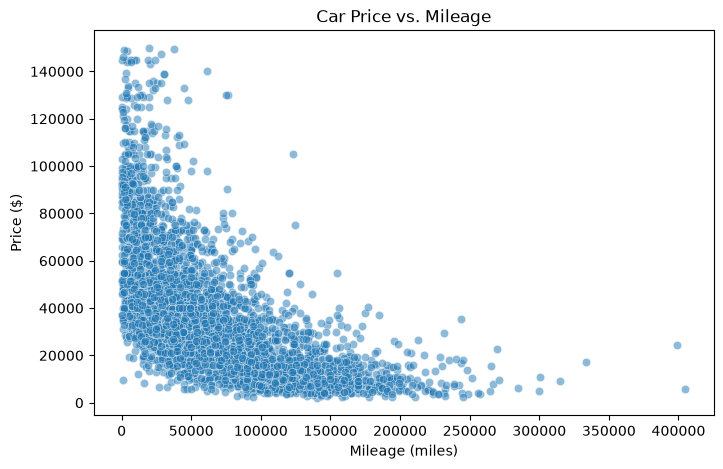

In [62]:
plt.figure(figsize=(8, 5))
filtered_df = df[df['price'] < 150000]
sns.scatterplot(data=filtered_df, x='milage', y='price', alpha=0.5)
plt.title('Car Price vs. Mileage')
plt.xlabel('Mileage (miles)')
plt.ylabel('Price ($)')
plt.show()

## 13. Correlation Heatmap Analysis

**Overview:**  
We generate a correlation matrix heatmap to analyze numerical linear relationships between 'model_year', 'milage', and 'price'.

**Key Insights:**
* **Correlation Calculation:** Used 'df[['model_year', 'milage', 'price']].corr()' to compute Pearson correlation coefficients.
* **Visualization:** Displayed the heatmap using 'sns.heatmap' with 'annot=True' for numerical labels and 'cmap='coolwarm''.
* **Findings:** Shows a negative correlation between 'milage' and 'model_year' (-0.62) and between 'milage' and 'price' (-0.31).

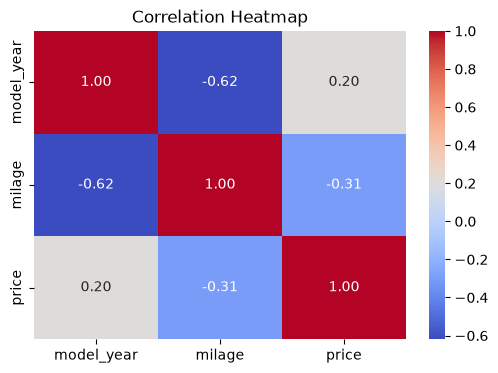

In [63]:
corr_matrix = df[['model_year', 'milage', 'price']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 14. Price Distribution by Fuel Type

**Overview:**  
We analyze how car prices vary across different fuel types using a box plot.

**Key Points:**
* **Categorical Comparison:** Grouped car prices by 'fuel_type' to examine median values and spread.
* **Filtering:** Applied 'df['price'] < 150000' to keep the scale clear and readable.
* **Formatting:** Rotated X-axis labels by 45 degrees ('rotation=45') to prevent category names from overlapping.

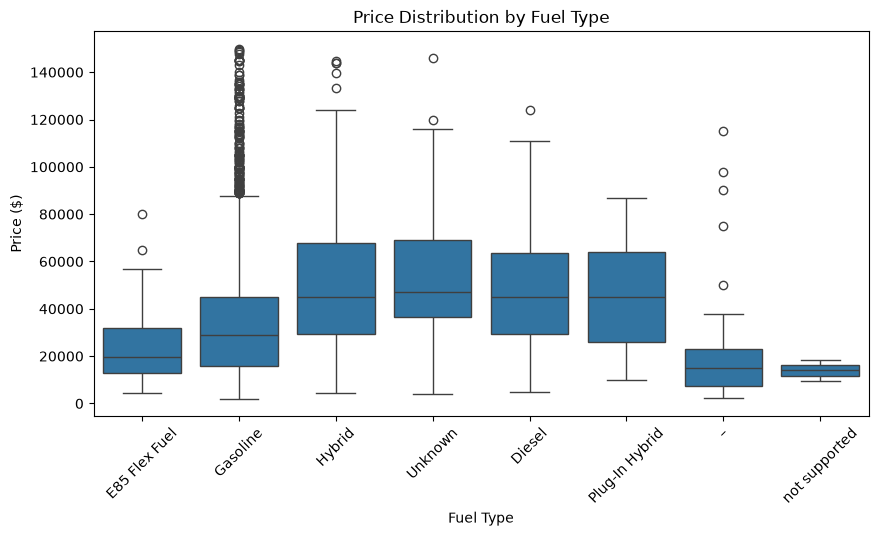

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['price'] < 150000], x='fuel_type', y='price')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()

## 15. Top 10 Car Brands Analysis

**Overview:**  
We visualize the frequency of the top 10 most common car brands in the dataset.

**Key Points:**
* **Identification:** Used 'value_counts().head(10)' to extract the top 10 brands with the highest number of listings.
* **Visualization:** Created a bar chart using 'sns.countplot' and ordered the bars by frequency ('order=top_brands').
* **Formatting:** Rotated X-axis labels by 45 degrees ('rotation=45') for better legibility.

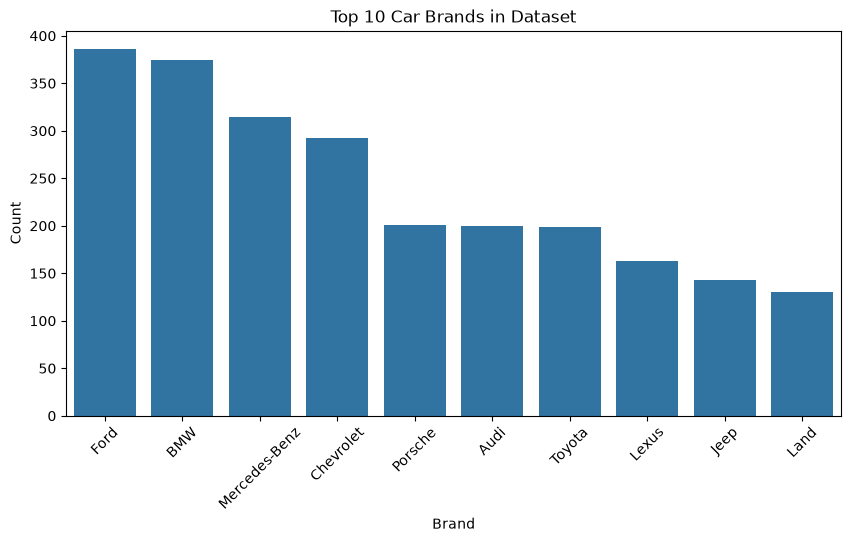

In [65]:
plt.figure(figsize=(10, 5))
top_brands = df['brand'].value_counts().head(10).index
sns.countplot(data=df[df['brand'].isin(top_brands)], x='brand', order=top_brands)
plt.title('Top 10 Car Brands in Dataset')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()